In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.isna().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
X=df[['Annual Income (k$)','Spending Score (1-100)']]

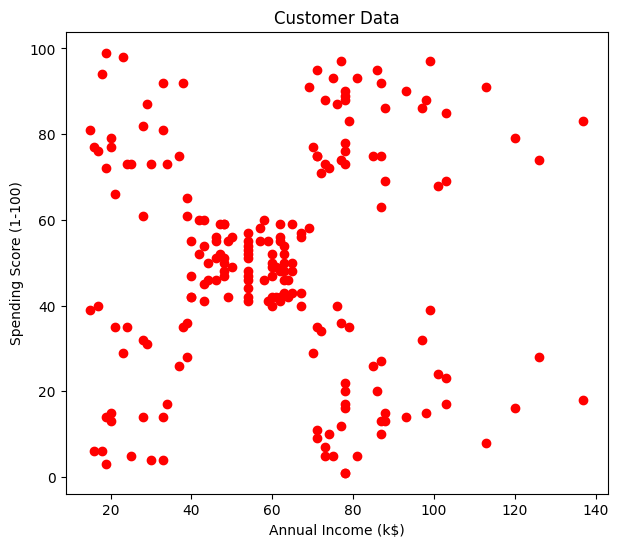

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'],c='red')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Data')
plt.show()

In [ ]:
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [ ]:
dbscan=DBSCAN(eps=0.3,min_samples=5)
clusters=dbscan.fit_predict(X)

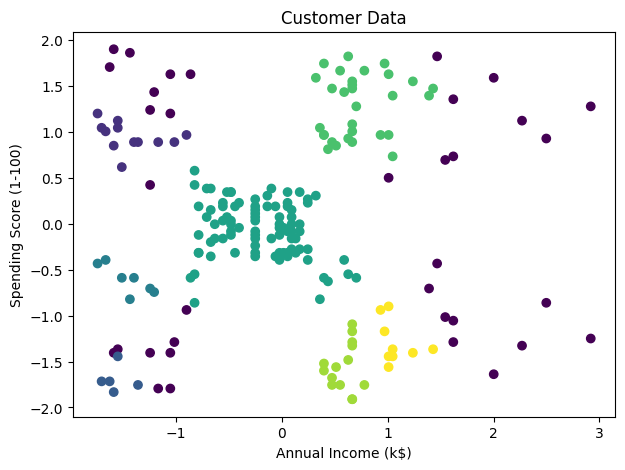

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X[:,0],X[:,1],c=clusters)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Data')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
print("Silhouette score : ",silhouette_score(X,clusters))

Silhouette score :  0.31614121976731185


In [ ]:
eps_value=[0.2,0.3,0.5]
for i in eps_value:
  print(f"\nEvaluation DBSCAN using eps={i}")
  dbscan=DBSCAN(eps=i,min_samples=5)
  labels=dbscan.fit_predict(X)

  #no.of clusters
  unique_labels=set(labels)
  n_clusters=len(unique_labels) - (1 if -1 in labels else 0)

  #no.of noise points
  n_noise=list(labels).count(-1)
  noise_ratio=n_noise/len(labels)
  print(f"Number of clusters : {n_clusters}")
  print(f"Number of noise points : ",round(n_noise,2))
  print(f"Noise ratio : ",round(noise_ratio,2))

  #silhouette score
  if n_clusters>1:
    X_clustered=X[labels!=-1]
    labels_clustered=labels[labels!=-1]
    score=silhouette_score(X_clustered,labels_clustered)
    print(f"Silhouette score : ",round(score,2))



Evaluation DBSCAN using eps=0.2
Number of clusters : 7
Number of noise points :  77
Noise ratio :  0.39
Silhouette score :  0.59

Evaluation DBSCAN using eps=0.3
Number of clusters : 7
Number of noise points :  35
Noise ratio :  0.17
Silhouette score :  0.52

Evaluation DBSCAN using eps=0.5
Number of clusters : 2
Number of noise points :  8
Noise ratio :  0.04
Silhouette score :  0.39


### **NewYorkCityTaxiTripDuration**

To analyze pickup locations and identify natural demand clusters, without knowing how many hotspots exist.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving NewYorkCityTaxiTripDuration.csv to NewYorkCityTaxiTripDuration.csv


**1.Load the Dataset**

Load the CSV file into a pandas DataFrame.

 Display the first 5 rows of the dataset.

In [1]:
import pandas as pd
df = pd.read_csv(
    "NewYorkCityTaxiTripDuration.csv",
    usecols=["pickup_latitude", "pickup_longitude"],
    dtype={
        "pickup_latitude": "float32",
        "pickup_longitude": "float32"
    },
    nrows=10000
)
print("Dataset preview:")
df.head()

Dataset preview:


,pickup_longitude,pickup_latitude
0,-73.982155,40.767937
1,-73.980415,40.738564
2,-73.979027,40.763939
3,-74.010040,40.719971
4,-73.973053,40.793209


In [2]:
df.shape

(10000, 2)

**2.Feature Selection**

Extract the following columns:

pickup_latitude, pickup_longitude

 Store them in a variable named X.

In [3]:
X = df[['pickup_latitude', 'pickup_longitude']]
print(X.head())

   pickup_latitude  pickup_longitude
0        40.767937        -73.982155
1        40.738564        -73.980415
2        40.763939        -73.979027
3        40.719971        -74.010040
4        40.793209        -73.973053


**3.Data Preprocessing**

Apply StandardScaler to scale the selected features.

Store the scaled data in X_scaled.

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**4.DBSCAN Model – Experiment 1**

Apply DBSCAN with: eps = 0.2 min_samples = 5

Store cluster labels in labels_1.

In [5]:
from sklearn.cluster import DBSCAN
db1 = DBSCAN(eps=0.2, min_samples=5)
labels_1 = db1.fit_predict(X_scaled)

**5.DBSCAN Model – Experiment 2**

Apply DBSCAN with: eps = 0.3 min_samples = 5

Store cluster labels in labels_2.

In [6]:
db2 = DBSCAN(eps=0.3, min_samples=5)
labels_2 = db2.fit_predict(X_scaled)

**6.DBSCAN Model – Experiment 3**

Apply DBSCAN with: eps = 0.5 min_samples = 5

Store cluster labels in labels_3.

In [7]:
db3 = DBSCAN(eps=0.5, min_samples=5)
labels_3 = db3.fit_predict(X_scaled)

In [8]:
experiments = {
    'Experiment 1': labels_1,
    'Experiment 2': labels_2,
    'Experiment 3': labels_3
}

**7.Cluster Evaluation For each experiment:**

Print: Number of clusters (excluding noise)

Number of noise points Noise ratio

In [9]:
for name, labels in experiments.items():
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)

    print(f"{name}:")
    print(f"  Number of clusters (excluding noise): {n_clusters}")
    print(f"  Number of noise points: {n_noise}")
    print(f"  Noise ratio: {noise_ratio:.4f}")
    print("-"*40)

Experiment 1:
  Number of clusters (excluding noise): 11
  Number of noise points: 88
  Noise ratio: 0.0088
----------------------------------------
Experiment 2:
  Number of clusters (excluding noise): 4
  Number of noise points: 42
  Noise ratio: 0.0042
----------------------------------------
Experiment 3:
  Number of clusters (excluding noise): 2
  Number of noise points: 23
  Noise ratio: 0.0023
----------------------------------------


**8.Silhouette Score Calculation**

Remove noise points (-1) from each experiment.

Calculate and print the Silhouette Score for: Experiment 1, Experiment 2, Experiment 3

If silhouette score is not applicable, print "Not Applicable".

In [12]:
import numpy as np
from sklearn.metrics import silhouette_score
for name, labels in experiments.items():
    mask = labels != -1  # Exclude noise
    if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
        score = silhouette_score(X_scaled[mask], labels[mask])
        print(f"{name} Silhouette Score: {score:.4f}")
    else:
        print(f"{name} Silhouette Score: Not Applicable")

Experiment 1 Silhouette Score: 0.0432
Experiment 2 Silhouette Score: 0.5719
Experiment 3 Silhouette Score: 0.8111


**9.Visualization**

For each experiment:

Plot pickup locations using a scatter plot.

Color points based on cluster labels.

Highlight noise points using a separate color.

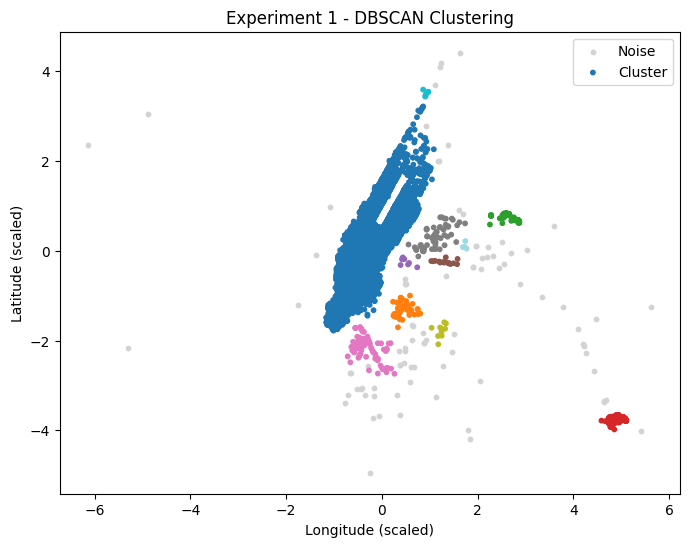

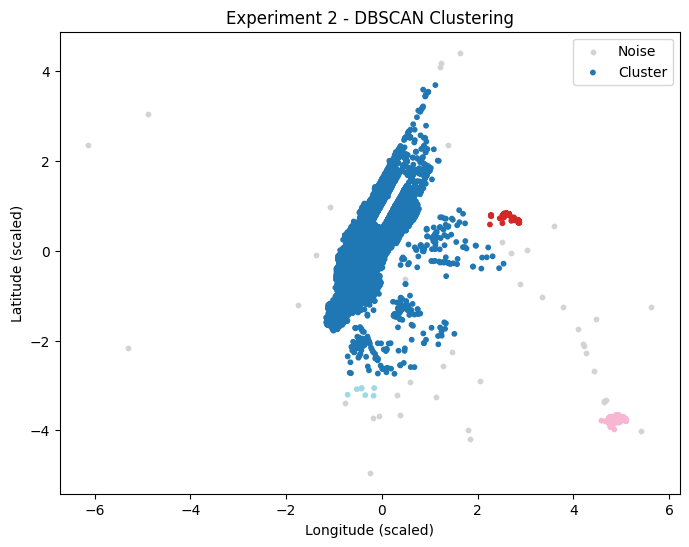

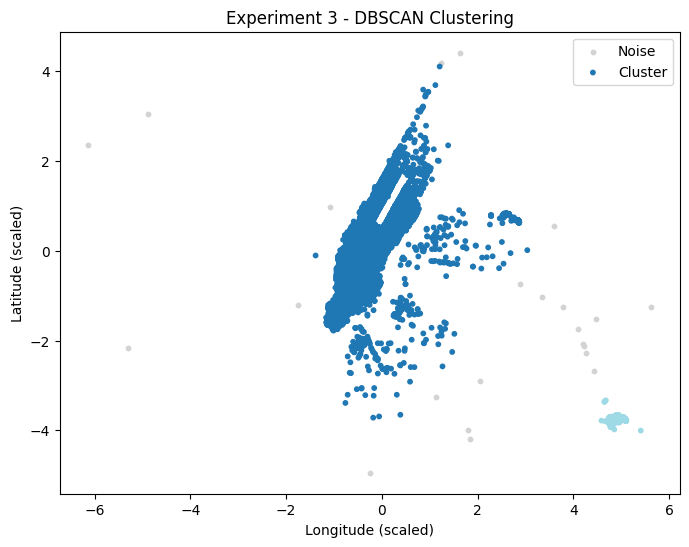

In [14]:
import matplotlib.pyplot as plt
for name, labels in experiments.items():
    plt.figure(figsize=(8,6))

    noise_mask = labels == -1
    plt.scatter(X_scaled[noise_mask, 1], X_scaled[noise_mask, 0],
                c='lightgrey', s=10, label='Noise')

    cluster_mask = labels != -1
    plt.scatter(X_scaled[cluster_mask, 1], X_scaled[cluster_mask, 0],
                c=labels[cluster_mask], cmap='tab20', s=10, label='Cluster')

    plt.title(f"{name} - DBSCAN Clustering")
    plt.xlabel("Longitude (scaled)")
    plt.ylabel("Latitude (scaled)")
    plt.legend()
    plt.show()

**10.Best Model Selection**

Based on:

Number of clusters

Noise ratio

Silhouette score

Print: Best eps value

In [ ]:
import numpy as np
best_eps = None
best_score = -1

for name, labels in experiments.items():
    mask = labels != -1
    if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
        score = silhouette_score(X_scaled[mask], labels[mask])
        noise_ratio = list(labels).count(-1) / len(labels)
        if score > best_score and noise_ratio < 0.5:
            best_score = score
            best_eps = float(name.split()[-1]) if name.split()[-1].replace('.','').isdigit() else None

print(f"Best eps value = {best_eps if best_eps else 'Choose based on silhouette & noise ratio'}")